In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

In [60]:
data=pd.read_csv('Ice Cream Sales and Temperature.csv')

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Date                   45 non-null     object
 1   Time                   45 non-null     object
 2   Temperature (Celsius)  45 non-null     int64 
 3   Ice Cream Sales        45 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 1.5+ KB


In [62]:
data.duplicated().sum()

np.int64(0)

In [63]:
data.isna().sum()

Date                     0
Time                     0
Temperature (Celsius)    0
Ice Cream Sales          0
dtype: int64

In [64]:
data.head(1)

,Date,Time,Temperature (Celsius),Ice Cream Sales
0,2023-01-01,08:00,18,20


In [65]:
X = data[['Temperature (Celsius)']]
y = data['Ice Cream Sales']


In [66]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=24)

In [67]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [68]:
transformer = ColumnTransformer([
    ('num', num_pipeline, make_column_selector(dtype_include=np.number))
])


In [69]:
model_pipeline = Pipeline([
    ('preprocessing', transformer),
    ('poly', PolynomialFeatures(degree=2, include_bias=True)),
    ('model', LinearRegression())
])

In [70]:
model_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000019160D3E9C0>)])),
                ('poly', PolynomialFeatures()), ('model', LinearRegression())])

In [78]:
y_train_pred=model_pipeline.predict(x_train)

In [79]:
y_test_pred=model_pipeline.predict(x_test)

In [80]:
sqrt(mean_squared_error(y_train,y_train_pred))

3.3536831024565803

In [81]:
r2_score(y_train,y_train_pred)

0.9058635278466423

In [82]:
sqrt(mean_squared_error(y_test,y_test_pred))

2.4252644136399324

In [83]:
r2_score(y_test,y_test_pred)

0.5982303636565407

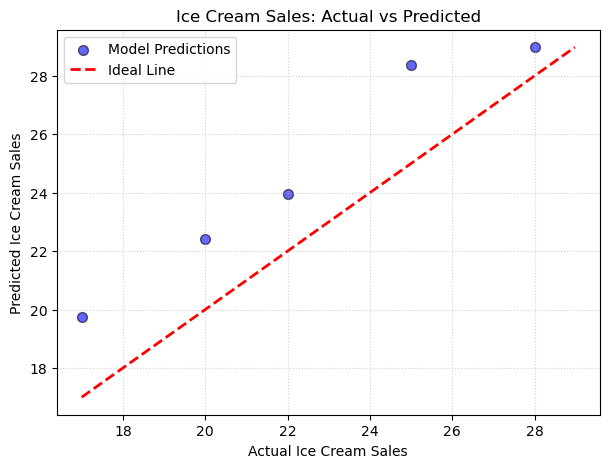

In [84]:
import matplotlib.pyplot as plt

def make_prediction_and_plot(model, x_data, y_actual):
    y_pred = model.predict(x_data)
    
    plt.figure(figsize=(7, 5))
    plt.scatter(y_actual, y_pred, color='blue', alpha=0.6, edgecolors='k', s=50, label='Model Predictions')
    
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Ideal Line')
    
    plt.xlabel('Actual Ice Cream Sales')
    plt.ylabel('Predicted Ice Cream Sales')
    plt.title('Ice Cream Sales: Actual vs Predicted')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    
    return y_pred
predictions = make_prediction_and_plot(model_pipeline, x_test, y_test)
